In [1]:
import pandas as pd
import numpy as np
import itertools
from io import StringIO
from tabulate import tabulate 

# models
import statsmodels.formula.api as smf
import statsmodels.api as sm

# stats
from scipy.stats import zscore, chi2_contingency, fisher_exact
from scipy.stats.distributions import chi2
from scipy.stats.contingency import odds_ratio
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [2]:
df = pd.read_csv("GANESH_clean.csv", index_col = 0)
df = df[df['S.N.']<1712]
print(f'Number of children in table: {df.shape[0]}')

Number of children in table: 1681


In [3]:
# correct name for smf interpretation
df['Birth_weight_below_2_5kg'] = df['Birth_weight_below_2.5kg']
df['c_section'] = df['c-section']

In [4]:
# aberrant GMs
df['Aberrant_GM_MOS_below20'] = df['Aberrant_GM_MOS_below20'].astype(int)
df['Aberrant_GM_MOS_below23'] = df['Aberrant_GM_MOS_below23'].astype(int)

In [5]:
# make lowest caste, reference class
df['Cast_code_extract'] = pd.Categorical(df['Cast_code_extract'], categories=['SC/ST', 'OBC', 'GENERAL'], ordered=True)

### Functions

In [6]:
def get_association_res(data, y_col, x_col):
    # contingency table
    table = pd.crosstab(data[x_col], data[y_col])
    if table.shape != (2, 2):
        print(f"Warning: Contingency table not 2x2. Actual shape: {table.shape}")
        return None, None, None, None
    print("=" * 70)
    print(f"Contingency Table: {x_col} vs Aberrant GMs")
    print("-" * 70)
    print(tabulate(table, headers=table.columns, tablefmt='github', showindex=True))
    print(f"\nMissing values in {x_col}: {data[x_col].isna().sum()}\n")

    smallest_cell = table.values.min()
    if smallest_cell > 5:
        # Chi-square test for independence
        print("Pearson’s Chi² Test for Independence")
        print("-" * 70)
        res = chi2_contingency(table.values)
    else:
        # Fisher's exact test
        print("Fisher’s Exact Test")
        print("-" * 70)
        res = fisher_exact(table.values)
    p = res.pvalue
    print(f"{'p-value':<25}: {p:>10.4f}\n")

    # Odds ratio and 95% confidence interval
    print("Odds Ratio and 95% Confidence Interval")
    print("-" * 70)
    or_res = odds_ratio(table.values)
    low, high = or_res.confidence_interval(confidence_level=0.95)
    print(f"{'Odds Ratio':<25}: {or_res.statistic:>10.3f}")
    print(f"{'95% CI Lower Bound':<25}: {low:>10.3f}")
    print(f"{'95% CI Upper Bound':<25}: {high:>10.3f}")
    print("=" * 70 + "\n")

    return or_res.statistic, low, high, p

In [7]:
def process_data_for_regression(df, X_cols, y_col, x_col_numeric=None, zscore_numeric=True, high_risk=False):
    # Drop missing outcome
    df_model = df[~df[y_col].isna()]
    print(f'Number of children in table with non-missing {y_col}: {df_model.shape[0]}')

    # High-risk filter
    if high_risk:
        df_model = df_model[
            (df_model['medical_pregnancy_problem'] == 'Problem') |
            (df_model['Preterm'] == True)
        ]
        print(f'Number of high risk children in table with outcome: {df_model.shape[0]}')

    # Drop missing rows in X variables
    df_model_fullX = df_model.copy()
    for col in X_cols:
        df_model_fullX = df_model_fullX[~df_model_fullX[col].isna()]

    # Drop missing numeric y (if provided)
    if x_col_numeric is not None:
        df_model_fullX = df_model_fullX[~df_model_fullX[x_col_numeric].isna()]
        print(f'Number of children with non-missing {x_col_numeric}: {df_model_fullX.shape[0]}')

        if zscore_numeric:
            df_model_fullX[x_col_numeric] = zscore(df_model_fullX[x_col_numeric].astype(float))

    n_dropped = df_model.shape[0] - df_model_fullX.shape[0]
    print(f'Number of children in table with non-missing {y_col} and all X vars: {df_model_fullX.shape[0]} ({n_dropped} dropped)')
    
    # One-hot encode categorical X variables
    X = pd.get_dummies(df_model_fullX[X_cols], drop_first=True).astype(int)

    # Build final dataframe
    df_model_fullX_encoded = pd.concat([df_model_fullX[y_col], X],axis=1)

    # Add numeric predictor if provided
    if x_col_numeric is not None:
        df_model_fullX_encoded[x_col_numeric] = df_model_fullX[x_col_numeric]

    print('One-hot encoding feature columns completed.')

    return df_model_fullX_encoded, df_model_fullX

In [8]:
def get_vif(df_encoded, y_col):
    # vif
    X = df_encoded.drop(columns=[y_col])
    vif_data = pd.DataFrame()
    vif_data["feature"] = list(X.columns) 

    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                            for i in range(len(X.columns))]
    print('\nVariance Inflation Factors:')
    print(tabulate(vif_data, tablefmt='github', headers='keys', showindex=False))
    return

In [9]:
def likelihood_ratio_test(null_model, full_model):
    LR1 = null_model.llf
    LR2 = full_model.llf

    df_diff = full_model.df_model - null_model.df_model
    LR_stat = -2*(LR1-LR2)
    p = chi2.sf(LR_stat, df_diff)
    # print(f"Likelihood ratio statistic: {LR_stat:.3f}")
    # print(f"Degrees of freedom: {df_diff:.0f}")
    print(f"p-value: {p:.4g}")

    return p

In [10]:
def linear_regression_procedure(df_encoded, y_col):
    X = df_encoded.drop(columns=[y_col])

    # null model
    mod0 = smf.ols(formula= f'{y_col} ~ 1', data=df_encoded)
    res0 = mod0.fit()

    # no interactions 
    mod1 = smf.ols(formula= f'{y_col} ~ {'+'.join(X.columns)}', data=df_encoded)
    res1 = mod1.fit()

    print('Likelihood Ratio Test between null model and full model:')
    p = likelihood_ratio_test(res0, res1)
    if p < 0.05:
        print("The full model is significantly better than the null model.\n")
        results_as_html = res1.summary().tables[1].as_html()
        res1_summary = pd.read_html(StringIO(results_as_html), header=0, index_col=0)[0]
        res1_summary.rename(columns={'P>|t|': 'P'}, inplace = True)
        res1_summary['P (S.N)'] = res1.pvalues.apply(lambda x: f"{x:.4E}")

        print('\nFull model results:')
        print(tabulate(res1_summary.rename(columns={'P>|t|': 'P'}), tablefmt = 'github', headers='keys'))
    else:
        print("The full model is NOT significantly better than the null model.\n")
    
    return res1, res1_summary

In [11]:
def logistic_regression_procedure(df_encoded, y_col):
    # res1_summary['Odds Ratio'] = np.exp(res1.params)
    X = df_encoded.drop(columns=[y_col])

    # null model
    mod0 = smf.logit(formula= f'{y_col} ~ 1', data=df_encoded)
    # res0 = mod0.fit(method='bfgs', maxiter = 30000)
    res0 = mod0.fit()


    # no interactions 
    mod1 = smf.logit(formula= f'{y_col} ~ {'+'.join(X.columns)}', data=df_encoded)
    # res1 = mod1.fit(method='bfgs', maxiter = 30000)
    res1 = mod1.fit()

    print('Likelihood Ratio Test between null model and full model:')
    p = likelihood_ratio_test(res0, res1)
    # print(res1.summary2(float_format='%.10E').tables[1])
    if p < 0.05:
        results_as_html = res1.summary().tables[1].as_html()
        res1_summary = pd.read_html(StringIO(results_as_html), header=0, index_col=0)[0]
        res1_summary['Odds Ratio'] = round(np.exp(res1.params), 3)
        res1_summary['coef'] = round(res1.params, 3)

        # 95% CI for coefficients
        conf = res1.conf_int()
        conf.columns = ['CI_lower', 'CI_upper']

        # Convert to odds ratio scale
        res1_summary['OR 2.5%'] = round(np.exp(conf['CI_lower']), 3)
        res1_summary['OR 97.5%'] = round(np.exp(conf['CI_upper']), 3)
        res1_summary.rename(columns={'P>|z|': 'P'}, inplace = True)
        res1_summary['P (S.N)'] = res1.pvalues.apply(lambda x: f"{x:.4E}")
        
        print('\nFull model results:')
        print(tabulate(res1_summary, tablefmt = 'github', headers='keys'))
    else:
        print("The full model is NOT significantly better than the null model.\n")
        res1_summary = np.nan

    return res1_summary

In [12]:
def run_modeling_procedure(df, X_cols, y_col, x_col_numeric=None, zscore_numeric=True, high_risk=False, model_type='logistic'):
    
    # get data for regression
    df_encoded, df_model_fullX = process_data_for_regression(df, X_cols, y_col, x_col_numeric, zscore_numeric, high_risk)

    # test multicollinearity
    get_vif(df_encoded, y_col)
    print("\n")
    # fit linear regression model
    print("="*80)
    if model_type == 'logistic':
        res_table = logistic_regression_procedure(df_encoded, y_col)
    elif model_type == 'linear':
        res_table = linear_regression_procedure(df_encoded, y_col)
    else:
        raise ValueError("model_type must be 'logistic' or 'linear'")

    return res_table

# MOS score

In [15]:
# MOS score 

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'Preterm',
     'medical_pregnancy_problem', 
     'c_section', 
     'institution_delivery', 
     'malnourished', 
     'Birth_weight_below_2_5kg']

MOS_res, MOS_res_table = run_modeling_procedure(df, X_cols, 'Final_MOS_score', model_type='linear')

Number of children in table with non-missing Final_MOS_score: 1016
Number of children in table with non-missing Final_MOS_score and all X vars: 943 (73 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                           |     VIF |
|-----------------------------------|---------|
| malnourished                      | 1.21465 |
| Sex_M                             | 1.98627 |
| Cast_code_extract_OBC             | 2.52884 |
| Cast_code_extract_GENERAL         | 1.20944 |
| Preterm_True                      | 1.12409 |
| medical_pregnancy_problem_Problem | 1.16243 |
| c_section_True                    | 1.35802 |
| institution_delivery_True         | 3.9522  |
| Birth_weight_below_2_5kg_True     | 1.34517 |


Likelihood Ratio Test between null model and full model:
p-value: 2.175e-12
The full model is significantly better than the null model.


Full model results:
|                                   |    coef |   std err |      t |     P |  

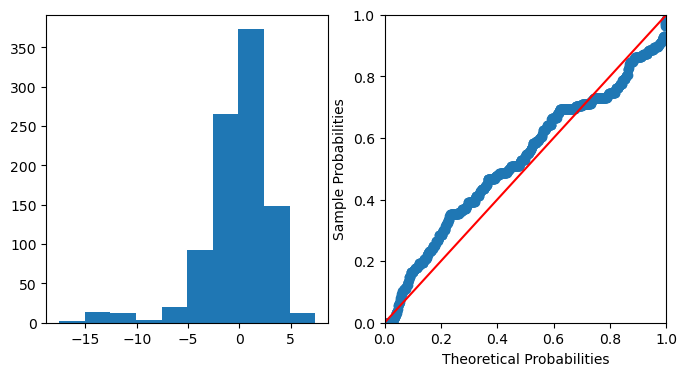

In [16]:
# check normality of residuals
MOS_residuals = MOS_res.resid

probplot = sm.ProbPlot(MOS_residuals, fit=True) 

fig, ax = plt.subplots(1, 2, figsize = (8, 4) ) 

probplot.ppplot(line='45', ax = ax[1]) 
ax[0].hist(MOS_residuals)

plt.show()

In [17]:
# MOS score 
# High risk 

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'c_section', 
     'institution_delivery', 
     'malnourished', 
     'Birth_weight_below_2_5kg']

MOS_HR_res, MOS_HR_res_table = run_modeling_procedure(df, X_cols, 'Final_MOS_score', model_type='linear', high_risk=True)

Number of children in table with non-missing Final_MOS_score: 1016
Number of high risk children in table with outcome: 104
Number of children in table with non-missing Final_MOS_score and all X vars: 97 (7 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                       |     VIF |
|-------------------------------|---------|
| malnourished                  | 1.38104 |
| Sex_M                         | 1.9364  |
| Cast_code_extract_OBC         | 1.94942 |
| Cast_code_extract_GENERAL     | 1.15311 |
| c_section_True                | 1.66003 |
| Birth_weight_below_2_5kg_True | 1.57787 |


Likelihood Ratio Test between null model and full model:
p-value: 0.003699
The full model is significantly better than the null model.


Full model results:
|                               |    coef |   std err |      t |     P |   [0.025 |   0.975] |    P (S.N) |
|-------------------------------|---------|-----------|--------|-------|----------|----------

# Aberrant GMs 

In [18]:
# Aberrant GMs (MOS < 20)

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'Preterm',
     'medical_pregnancy_problem', 
     'c_section', 
     'institution_delivery', 
     'malnourished', 
     'Birth_weight_below_2_5kg']

Ab20_res_table = run_modeling_procedure(df, X_cols, 'Aberrant_GM_MOS_below20')

Number of children in table with non-missing Aberrant_GM_MOS_below20: 1681
Number of children in table with non-missing Aberrant_GM_MOS_below20 and all X vars: 1565 (116 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                           |     VIF |
|-----------------------------------|---------|
| malnourished                      | 1.23402 |
| Sex_M                             | 1.99851 |
| Cast_code_extract_OBC             | 2.62232 |
| Cast_code_extract_GENERAL         | 1.20144 |
| Preterm_True                      | 1.17997 |
| medical_pregnancy_problem_Problem | 1.18937 |
| c_section_True                    | 1.3424  |
| institution_delivery_True         | 4.19298 |
| Birth_weight_below_2_5kg_True     | 1.40216 |


Optimization terminated successfully.
         Current function value: 0.394266
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.363112
         Iterations 6
Likelihood Rat

In [19]:
# Aberrant GMs (MOS < 20)
# High risk

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'c_section', 
     # 'institution_delivery', 
     'malnourished', 
     'Birth_weight_below_2_5kg']

Ab20_HR_res_table = run_modeling_procedure(df, X_cols, 'Aberrant_GM_MOS_below20', high_risk = True)

Number of children in table with non-missing Aberrant_GM_MOS_below20: 1681
Number of high risk children in table with outcome: 198
Number of children in table with non-missing Aberrant_GM_MOS_below20 and all X vars: 187 (11 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                       |     VIF |
|-------------------------------|---------|
| malnourished                  | 1.45206 |
| Sex_M                         | 1.83299 |
| Cast_code_extract_OBC         | 1.86413 |
| Cast_code_extract_GENERAL     | 1.12663 |
| c_section_True                | 1.46629 |
| Birth_weight_below_2_5kg_True | 1.7417  |


Optimization terminated successfully.
         Current function value: 0.539212
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.485052
         Iterations 6
Likelihood Ratio Test between null model and full model:
p-value: 0.002493

Full model results:
|                               |   coef

In [20]:
# Aberrant GMs (MOS < 23)

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'Preterm',
     'medical_pregnancy_problem', 
     'c_section', 
     'institution_delivery', 
     'malnourished', 
     'Birth_weight_below_2_5kg']

Ab23_res_table = run_modeling_procedure(df, X_cols, 'Aberrant_GM_MOS_below23')

Number of children in table with non-missing Aberrant_GM_MOS_below23: 1681
Number of children in table with non-missing Aberrant_GM_MOS_below23 and all X vars: 1565 (116 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                           |     VIF |
|-----------------------------------|---------|
| malnourished                      | 1.23402 |
| Sex_M                             | 1.99851 |
| Cast_code_extract_OBC             | 2.62232 |
| Cast_code_extract_GENERAL         | 1.20144 |
| Preterm_True                      | 1.17997 |
| medical_pregnancy_problem_Problem | 1.18937 |
| c_section_True                    | 1.3424  |
| institution_delivery_True         | 4.19298 |
| Birth_weight_below_2_5kg_True     | 1.40216 |


Optimization terminated successfully.
         Current function value: 0.553571
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.523468
         Iterations 5
Likelihood Rat

In [21]:
# Aberrant GMs (MOS < 23)
# High risk

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'c_section', 
     # 'institution_delivery', 
     'malnourished', 
     'Birth_weight_below_2_5kg']

Ab23_HR_res_table = run_modeling_procedure(df, X_cols, 'Aberrant_GM_MOS_below23', high_risk = True)

Number of children in table with non-missing Aberrant_GM_MOS_below23: 1681
Number of high risk children in table with outcome: 198
Number of children in table with non-missing Aberrant_GM_MOS_below23 and all X vars: 187 (11 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                       |     VIF |
|-------------------------------|---------|
| malnourished                  | 1.45206 |
| Sex_M                         | 1.83299 |
| Cast_code_extract_OBC         | 1.86413 |
| Cast_code_extract_GENERAL     | 1.12663 |
| c_section_True                | 1.46629 |
| Birth_weight_below_2_5kg_True | 1.7417  |


Optimization terminated successfully.
         Current function value: 0.635271
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.577410
         Iterations 5
Likelihood Ratio Test between null model and full model:
p-value: 0.001407

Full model results:
|                               |   coef

# Adverse outcome

In [22]:
X_cols_common = ['Sex',
     'Cast_code_extract',
     'Preterm',
     'medical_pregnancy_problem',
     'c_section',
     'institution_delivery',
     'malnourished',
     'Birth_weight_below_2_5kg']

In [23]:
# Diagnosed Disorder (with Aberrant GMs (MOS < 20))

# predictors
X_cols = X_cols_common + ['Aberrant_GM_MOS_below20']

DD20_res_table = run_modeling_procedure(df, X_cols, 'Diagnosed_disorder')

Number of children in table with non-missing Diagnosed_disorder: 1642
Number of children in table with non-missing Diagnosed_disorder and all X vars: 1528 (114 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                           |     VIF |
|-----------------------------------|---------|
| malnourished                      | 1.28786 |
| Aberrant_GM_MOS_below20           | 1.24771 |
| Sex_M                             | 2.00163 |
| Cast_code_extract_OBC             | 2.60214 |
| Cast_code_extract_GENERAL         | 1.19727 |
| Preterm_True                      | 1.17801 |
| medical_pregnancy_problem_Problem | 1.18568 |
| c_section_True                    | 1.34234 |
| institution_delivery_True         | 4.27453 |
| Birth_weight_below_2_5kg_True     | 1.40522 |


Optimization terminated successfully.
         Current function value: 0.185993
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.12859

In [24]:
# Diagnosed Disorder (with Aberrant GMs (MOS < 20))
# High risk

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'c_section', 
     'malnourished', 
     # 'institution_delivery',
     'Birth_weight_below_2_5kg',
     'Aberrant_GM_MOS_below20']

DD20_HR_res_table = run_modeling_procedure(df, X_cols, 'Diagnosed_disorder', high_risk=True)

Number of children in table with non-missing Diagnosed_disorder: 1642
Number of high risk children in table with outcome: 195
Number of children in table with non-missing Diagnosed_disorder and all X vars: 184 (11 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                       |     VIF |
|-------------------------------|---------|
| malnourished                  | 1.50742 |
| Aberrant_GM_MOS_below20       | 1.40599 |
| Sex_M                         | 1.83112 |
| Cast_code_extract_OBC         | 1.86426 |
| Cast_code_extract_GENERAL     | 1.13703 |
| c_section_True                | 1.46432 |
| Birth_weight_below_2_5kg_True | 1.86156 |


Optimization terminated successfully.
         Current function value: 0.332189
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.217156
         Iterations 8
Likelihood Ratio Test between null model and full model:
p-value: 4.487e-07

Full model results:
|    

In [25]:
# Diagnosed Disorder (with Aberrant GMs (MOS < 23))

# predictors
X_cols = X_cols_common + ['Aberrant_GM_MOS_below23']

DD23_res_table = run_modeling_procedure(df, X_cols, 'Diagnosed_disorder')

Number of children in table with non-missing Diagnosed_disorder: 1642
Number of children in table with non-missing Diagnosed_disorder and all X vars: 1528 (114 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                           |     VIF |
|-----------------------------------|---------|
| malnourished                      | 1.28793 |
| Aberrant_GM_MOS_below23           | 1.39911 |
| Sex_M                             | 2.00212 |
| Cast_code_extract_OBC             | 2.60692 |
| Cast_code_extract_GENERAL         | 1.19824 |
| Preterm_True                      | 1.17434 |
| medical_pregnancy_problem_Problem | 1.18535 |
| c_section_True                    | 1.34237 |
| institution_delivery_True         | 4.46144 |
| Birth_weight_below_2_5kg_True     | 1.39865 |


Optimization terminated successfully.
         Current function value: 0.185993
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.13031

In [26]:
# Diagnosed Disorder (with Aberrant GMs (MOS < 23))
# High risk

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'c_section', 
     'malnourished', 
     # 'institution_delivery',
     'Birth_weight_below_2_5kg',
     'Aberrant_GM_MOS_below23']

DD23_HR_res_table = run_modeling_procedure(df, X_cols, 'Diagnosed_disorder', high_risk=True)

Number of children in table with non-missing Diagnosed_disorder: 1642
Number of high risk children in table with outcome: 195
Number of children in table with non-missing Diagnosed_disorder and all X vars: 184 (11 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                       |     VIF |
|-------------------------------|---------|
| malnourished                  | 1.54316 |
| Aberrant_GM_MOS_below23       | 1.5472  |
| Sex_M                         | 1.83031 |
| Cast_code_extract_OBC         | 1.88455 |
| Cast_code_extract_GENERAL     | 1.15627 |
| c_section_True                | 1.46872 |
| Birth_weight_below_2_5kg_True | 1.85308 |


Optimization terminated successfully.
         Current function value: 0.332189
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.227113
         Iterations 8
Likelihood Ratio Test between null model and full model:
p-value: 2.261e-06

Full model results:
|    

In [27]:
# Diagnosed Disorder (with MOS score)

# predictors
X_cols = X_cols_common

DDMOS_res_table = run_modeling_procedure(df, X_cols, 'Diagnosed_disorder', x_col_numeric='Final_MOS_score', zscore_numeric=True)

Number of children in table with non-missing Diagnosed_disorder: 1642
Number of children with non-missing Final_MOS_score: 921
Number of children in table with non-missing Diagnosed_disorder and all X vars: 921 (721 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                           |     VIF |
|-----------------------------------|---------|
| malnourished                      | 1.29919 |
| Sex_M                             | 1.99521 |
| Cast_code_extract_OBC             | 2.51613 |
| Cast_code_extract_GENERAL         | 1.20523 |
| Preterm_True                      | 1.12839 |
| medical_pregnancy_problem_Problem | 1.16668 |
| c_section_True                    | 1.36127 |
| institution_delivery_True         | 3.9594  |
| Birth_weight_below_2_5kg_True     | 1.35003 |
| Final_MOS_score                   | 1.10103 |


Optimization terminated successfully.
         Current function value: 0.168496
         Iterations 7
Optimization terminate

In [28]:
# Diagnosed Disorder (with MOS score)
# High risk

# predictors
X_cols = ['Sex',
     'Cast_code_extract',
     'c_section', 
     'malnourished', 
     # 'institution_delivery',
     'Birth_weight_below_2_5kg']

DDMOS_HR_res_table = run_modeling_procedure(df, X_cols, 'Diagnosed_disorder', x_col_numeric='Final_MOS_score', zscore_numeric=True, high_risk = True)

Number of children in table with non-missing Diagnosed_disorder: 1642
Number of high risk children in table with outcome: 195
Number of children with non-missing Final_MOS_score: 97
Number of children in table with non-missing Diagnosed_disorder and all X vars: 97 (98 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                       |     VIF |
|-------------------------------|---------|
| malnourished                  | 1.42618 |
| Sex_M                         | 1.95335 |
| Cast_code_extract_OBC         | 1.95876 |
| Cast_code_extract_GENERAL     | 1.16429 |
| c_section_True                | 1.85613 |
| Birth_weight_below_2_5kg_True | 1.59119 |
| Final_MOS_score               | 1.19054 |


Optimization terminated successfully.
         Current function value: 0.259203
         Iterations 6
         Current function value: 0.162965
         Iterations: 35
Likelihood Ratio Test between null model and full model:
p-value: 0.009286

Full mo

/Users/katerinapatsis/miniconda3/envs/ganesh/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
# Diagnosed Disorder (no GMA predictors)

# predictors
X_cols = X_cols_common

DD_nogma_res_table = run_modeling_procedure(df, X_cols, 'Diagnosed_disorder')

Number of children in table with non-missing Diagnosed_disorder: 1642
Number of children in table with non-missing Diagnosed_disorder and all X vars: 1528 (114 dropped)
One-hot encoding feature columns completed.

Variance Inflation Factors:
| feature                           |     VIF |
|-----------------------------------|---------|
| malnourished                      | 1.23016 |
| Sex_M                             | 2.00157 |
| Cast_code_extract_OBC             | 2.59919 |
| Cast_code_extract_GENERAL         | 1.19573 |
| Preterm_True                      | 1.17299 |
| medical_pregnancy_problem_Problem | 1.18518 |
| c_section_True                    | 1.34219 |
| institution_delivery_True         | 4.18471 |
| Birth_weight_below_2_5kg_True     | 1.38996 |


Optimization terminated successfully.
         Current function value: 0.185993
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.134604
         Iterations 8
Likelihood Ratio Test be

# Association between predictors

In [30]:
X_cols = ['Sex',
     'Cast_code_extract',
     'Preterm',
     'medical_pregnancy_problem', 
     'c_section', 
     'institution_delivery', 
     'malnourished', 
     'Birth_weight_below_2_5kg']

In [31]:
# One-hot encode categorical variables (drop first to avoid multicollinearity)
df_all_fullX = df.copy()

for col in X_cols:
    df_all_fullX = df_all_fullX[~df_all_fullX[col].isna()]
n_dropped = df.shape[0] - df_all_fullX.shape[0]
print(f'Number of children in table with MOS score and all X vars: {df_all_fullX.shape[0]} ({n_dropped} dropped)')

df_all_coded = pd.get_dummies(df_all_fullX[X_cols], drop_first=False).astype(int)
df_all_coded = df_all_coded[[col for col in df_all_coded.columns if ('F' not in col) & ('No problem' not in col)]]

Number of children in table with MOS score and all X vars: 1565 (116 dropped)


In [32]:
pairs = list(itertools.combinations(df_all_coded.columns, 2))
or_dict = {}
or_matrix = pd.DataFrame(np.nan, index=df_all_coded.columns, columns=df_all_coded.columns)
sig_matrix = pd.DataFrame('', index=df_all_coded.columns, columns=df_all_coded.columns)
ct_counts = np.array([[0,0],[0,0]])
ct_counts_index = []
ct_counts_p = []
for A, B in pairs:
    try:
        table = pd.crosstab(df_all_coded[A], df_all_coded[B])
        table.index = [f"{A}_{i}" for i in table.index]
        table.columns = [f"{B}_{j}" for j in table.columns]

        res = odds_ratio(table.values)
        or_val = res.statistic
        ci_low, ci_high = res.confidence_interval(confidence_level=0.95)
        smallest_cell = table.values.min()
        if smallest_cell > 5:
            test = "Chi-squared"
            p = chi2_contingency(table.values).pvalue
        else:
            test = "Fisher's Exact"
            p = fisher_exact(table.values).pvalue

        or_matrix.loc[A, B] = np.nan
        or_matrix.loc[B, A] = or_val  # make symmetric
    except Exception:
        or_matrix.loc[A, B] = np.nan
        or_matrix.loc[B, A] = np.nan
        p = np.nan
    if (not np.isnan(p)):
        if p < 0.05:
            print(f'\n{test} test p-value: {round(p, 5)}')
            print(tabulate(table, tablefmt = 'github', headers = 'keys'))
            ct_counts = np.concatenate([ct_counts, table.values])
            ct_counts_index.append([A, B])
            ct_counts_index.append([A, B])
            ct_counts_p.append([round(p, 3)])
            ct_counts_p.append([round(p, 3)])


            sig_matrix.loc[A, B] = ''
            sig_matrix.loc[B, A] = '*'
        else:
            sig_matrix.loc[A, B] = ''
            sig_matrix.loc[B, A] = ''


Chi-squared test p-value: 0.0
|                |   Preterm_True_0 |   Preterm_True_1 |
|----------------|------------------|------------------|
| malnourished_0 |             1351 |               35 |
| malnourished_1 |              156 |               23 |

Chi-squared test p-value: 0.00193
|                |   medical_pregnancy_problem_Problem_0 |   medical_pregnancy_problem_Problem_1 |
|----------------|---------------------------------------|---------------------------------------|
| malnourished_0 |                                  1266 |                                   120 |
| malnourished_1 |                                   150 |                                    29 |

Chi-squared test p-value: 0.02124
|                |   c_section_True_0 |   c_section_True_1 |
|----------------|--------------------|--------------------|
| malnourished_0 |               1094 |                292 |
| malnourished_1 |                155 |                 24 |

Chi-squared test p-value: 0.0


In [33]:
col_dict = {'malnourished': 'Undernutrition',
            'Birth_weight_below_2_5kg_True': 'Low birthweight', 
            'Cast_code_extract_GENERAL': 'Caste: General',
            'Cast_code_extract_OBC': 'Caste: OBC',
            'Cast_code_extract_SC/ST': 'Caste: SC/ST',
            'Preterm_True': 'Preterm birth',
            'Sex_M': 'Sex: Male',
            'c_section_True': 'Caesarean section',
            'medical_pregnancy_problem_Problem': 'Pregnancy and intrapartum\ncomplications', 
            'institution_delivery_True': 'Institutional delivery' }

In [34]:
pairs = list(itertools.combinations(col_dict.keys(), 2))

or_matrix = pd.DataFrame(np.nan, index=col_dict.keys(), columns=col_dict.keys())
sig_matrix = pd.DataFrame('', index=col_dict.keys(), columns=col_dict.keys())

# Store p-values and metadata
results = []

for A, B in pairs:
    try:
        table = pd.crosstab(df_all_coded[A], df_all_coded[B])
        table.index = [f"{A}_{i}" for i in table.index]
        table.columns = [f"{B}_{j}" for j in table.columns]

        res = odds_ratio(table.values)
        or_val = res.statistic

        smallest_cell = table.values.min()
        if smallest_cell > 5:
            test = "Chi-squared"
            p = chi2_contingency(table.values).pvalue
        else:
            test = "Fisher's Exact"
            p = fisher_exact(table.values).pvalue

        or_matrix.loc[B, A] = or_val

    except Exception:
        p = np.nan
        or_val = np.nan
        test = None

    results.append({
        "A": A,
        "B": B,
        "p_raw": p,
        "odds_ratio": or_val,
        "test": test,
        "table": table if 'table' in locals() else None
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Remove NaN p-values before correction
valid_mask = results_df["p_raw"].notna()
pvals = results_df.loc[valid_mask, "p_raw"].values

# Apply multiple testing correction (Benjamini-Hochberg)
reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# Store corrected p-values
results_df.loc[valid_mask, "p_corrected"] = pvals_corrected
results_df.loc[valid_mask, "significant"] = reject
results_df.loc[valid_mask, "significant_raw"] = results_df['p_raw']<0.05

# Fill significance matrix based on corrected p-values
for idx, row in results_df.iterrows():
    A, B = row["A"], row["B"]
    if row.get("significant", False):
        sig_matrix.loc[B, A] = '*'
    else:
        sig_matrix.loc[B, A] = ''

In [35]:
# Keep only significant results AFTER correction
sig_results = results_df[
    (results_df["significant_raw"] == True) &
    (results_df["p_corrected"].notna())
].copy()

ct_rows = []

for _, row in sig_results.iterrows():
    A = row["A"]
    B = row["B"]
    table = row["table"]
    p_corr = row["p_corrected"]
    p_raw = row["p_raw"]

    # Convert table back to counts
    counts = table.values

    for r in range(counts.shape[0]):
        false_count = counts[r, 0]
        true_count = counts[r, 1]
        total = false_count + true_count

        false_pct = 100 * false_count / total if total > 0 else 0
        true_pct = 100 * true_count / total if total > 0 else 0

        ct_rows.append({
            "A": A,
            "B": B,
            "False": f"{int(false_count)} ({false_pct:.1f})",
            "True": f"{int(true_count)} ({true_pct:.1f})",
            "p-value": round(p_raw, 3),
            "Corrected p-value": round(p_corr, 3)
        })

ct_counts_df = pd.DataFrame(ct_rows)
ct_counts_df = ct_counts_df[~(ct_counts_df['A'].str.contains('Cast_code_extract') & ct_counts_df['B'].str.contains('Cast_code_extract'))]

In [36]:
# rename columns

for col in ['p-value', 'Corrected p-value']:
    new_feature = []
    for i, val in enumerate(ct_counts_df[col].values):
        if i % 2 == 0:
            new_feature.append(val)
        else:
            new_feature.append('')
        
    ct_counts_df[col] = new_feature

ct_counts_df['A_'] = [False, True]*(int(ct_counts_df.shape[0]/2))
ct_counts_df = ct_counts_df[['A', 'B', 'A_', 'False', 'True', 'p-value', 'Corrected p-value']]

In [37]:
print(tabulate(ct_counts_df, tablefmt='github', headers='keys', showindex=False))

| A                             | B                                 | A_    | False       | True        |   p-value |   Corrected p-value |
|-------------------------------|-----------------------------------|-------|-------------|-------------|-----------|---------------------|
| malnourished                  | Birth_weight_below_2_5kg_True     | False | 1184 (85.4) | 202 (14.6)  |     0     |               0     |
| malnourished                  | Birth_weight_below_2_5kg_True     | True  | 96 (53.6)   | 83 (46.4)   |           |                     |
| malnourished                  | Preterm_True                      | False | 1351 (97.5) | 35 (2.5)    |     0     |               0     |
| malnourished                  | Preterm_True                      | True  | 156 (87.2)  | 23 (12.8)   |           |                     |
| malnourished                  | c_section_True                    | False | 1094 (78.9) | 292 (21.1)  |     0.021 |               0.064 |
| malnourished      

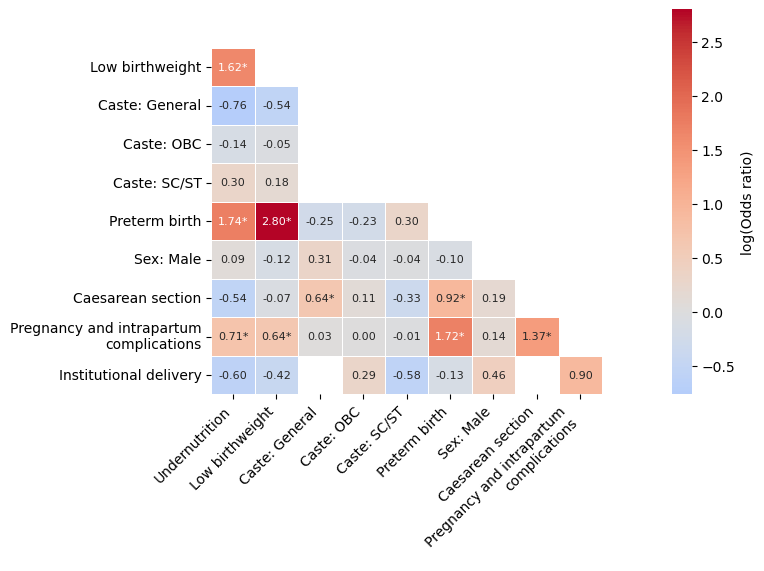

In [39]:
or_matrix = or_matrix.replace(np.inf, np.nan).replace(0, np.nan)
log_or = np.log(or_matrix)

annot = log_or.copy().astype(object)

for i in range(log_or.shape[0]):
    for j in range(log_or.shape[1]):
        if np.isnan(log_or.iloc[i, j]):
            annot.iloc[i, j] = ""
        else:
            star = sig_matrix.iloc[i, j]
            annot.iloc[i, j] = f"{log_or.iloc[i, j]:.2f}{star}"

fig, ax = plt.subplots(1,1, figsize=(7, 5))
sns.heatmap(
    log_or,
    cmap="coolwarm",
    center=0,
    annot=annot,
    annot_kws={"size": 8},
    fmt="",
    linewidths=0.5,
    ax = ax, 
    cbar_kws={'label': 'log(Odds ratio)'})

ax.set_xticks(ticks = np.arange(len(df_all_coded.columns)-1)+ 0.5, labels = list(col_dict.values())[:-1], rotation = 45, ha = 'right')
ax.set_yticks(ticks = np.arange(len(df_all_coded.columns)-1) + 1.5, labels = list(col_dict.values())[1:])

# plt.title("Pairwise Associations")

fig.savefig(
    "heatmap_predictor_associations.png",
    format="png",
    dpi=600,              # increase to 600 for print-quality
    bbox_inches="tight"
)
plt.show()

# Summary of models

In [40]:
model_dict_GMA = {
    'GMA: MOS-R': {
        'table': MOS_res_table,
        'model': 'Multiple linear regression'},
    'GMA: Aberrnat GMs (MOS-R < 23)': {
        'table': Ab23_res_table,
        'model': 'Multiple logistic regression'}}

In [41]:
model_dict_DD = {
    'Final outcome B': {
        'table': DD23_res_table,
        'model': 'Multiple logistic regression '},
    'Final outcome A': {
        'table': DDMOS_res_table,
        'model': 'Multiple logistic regression'}}

In [42]:
model_dict_HR = {
    'GMA: Aberrnat GMs (MOS-R < 23)': {
        'table': Ab23_HR_res_table,
        'model': 'Multiple logistic regression'},
    'Final outcome B': {
        'table': DD23_HR_res_table,
        'model': 'Multiple logistic regression'}}

In [43]:
def get_pretty_colnames(coef_summary):
    # rename columns
    for col in ['Screening tool: outcome variable', 'Model']:
        new_feature = []
        prev = ''
        for val in coef_summary[col].values:
            if val != prev:
                new_feature.append(val)
            else:
                new_feature.append('')
            prev = val
            
        coef_summary[col] = new_feature

    coef_summary = coef_summary[['Screening tool: outcome variable', 'Model', 'index', 'Estiamte (95% CI)', 'Odds Ratio (95% CI)', "P", "P (S.N)"]]
    coef_summary.rename(columns = {'index': 'Predictors'}, inplace = True)
    
    return coef_summary

In [44]:
def build_results_table(model_dict, process_cols=True):

    coef_summary = pd.DataFrame([])

    for scr, info_dict in model_dict.items():
        table = info_dict['table'].copy()
        table['Model'] = info_dict['model']
        table['Screening tool: outcome variable'] = scr
        table.drop(columns = ['std err'], inplace = True)
        coef_summary = pd.concat([coef_summary, table])

    coef_summary['Estiamte (95% CI)'] = coef_summary.apply(lambda x: f'{round(x['coef'], 3)} ({round(x["[0.025"], 3)}, {round(x["0.975]"], 3)})', axis = 1)
    coef_summary['Odds Ratio (95% CI)'] = coef_summary.apply(lambda x: np.nan if pd.isna(x['Odds Ratio']) else f'{round(x['Odds Ratio'], 3)} ({round(x["OR 2.5%"], 3)}, {round(x["OR 97.5%"], 3)})', axis = 1)
    coef_summary.reset_index(inplace = True)

    if process_cols:
        coef_summary = get_pretty_colnames(coef_summary)

    return coef_summary

In [45]:
coef_summary_HR = build_results_table(model_dict_HR)
coef_summary_HR.to_csv('Model_estimate_summary_HR.csv')

### Plot

In [46]:
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

In [47]:
label_map = {
    'malnourished': 'Undernutrition',
    'Sex_M': 'Sex: Male',
    'Cast_code_extract_OBC': 'Caste: OBC',
    'Cast_code_extract_GENERAL': 'Caste: General',
    'Preterm_True': 'Preterm birth',
    'medical_pregnancy_problem_Problem': 'Pregnancy and intrapartum\ncomplications',
    'c_section_True': 'Caesarean section',
    'institution_delivery_True': 'Institutional delivery',
    'Birth_weight_below_2_5kg_True': 'Low birthweight',
    'Aberrant_GM_MOS_below23': 'Aberrant GMs',
    'Final_MOS_score': 'MOS-R score'
}

In [48]:
coefs = build_results_table(model_dict_GMA, process_cols=False)

GMA_coefs = coefs[(coefs['index'] != 'Intercept')].copy()

GMA_coefs['index_label'] = GMA_coefs['index'].map(label_map)
GMA_coefs['stars'] = GMA_coefs['P'].apply(p_to_stars)

# order by min P per group (reversed)
order = (
    GMA_coefs.groupby('index')['P']
    .min()
    .sort_values()
    .index
)

# override order
order = ['malnourished',
       'Birth_weight_below_2_5kg_True', 'Cast_code_extract_OBC',
       'Cast_code_extract_GENERAL', 'Preterm_True', 'Sex_M', 'c_section_True',
       'medical_pregnancy_problem_Problem', 'institution_delivery_True']

GMA_coefs['index'] = pd.Categorical(
    GMA_coefs['index'],
    categories=order,
    ordered=True
)

GMA_coefs = GMA_coefs.sort_values(['index', 'P'])

In [49]:
GMA_coefs_out = GMA_coefs[['Screening tool: outcome variable', 
                            'index', 
                            'Estiamte (95% CI)', 
                            'Odds Ratio (95% CI)', 
                            'P', 
                            'P (S.N)']]
                            
GMA_coefs_out.sort_values(by = "Screening tool: outcome variable", ascending=False).to_csv('GMA_coefs_pretty_table.csv')

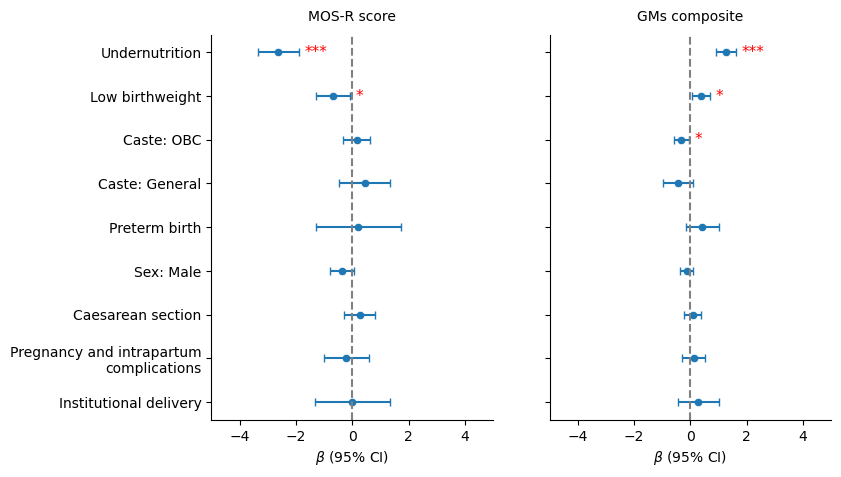

In [51]:
fig, ax = plt.subplots(1,2, figsize = (8,5), sharey = True)

scrs = pd.Series(['GMA: MOS-R', 'GMA: Aberrnat GMs (MOS-R < 23)'])
titles = ['MOS-R score', 'GMs composite']

for i, scr in enumerate(scrs):
    data = GMA_coefs[GMA_coefs['Screening tool: outcome variable']==scr]
    sns.scatterplot(
        data=data,
        y='index_label',
        x='coef',
        # hue='Screening tool: outcome variable',
        # palette=palette,
        ax = ax[i]
    )

    for _, row in data.iterrows():
        # color = palette[row['Screening tool: outcome variable']]
        ax[i].errorbar(
            x=row['coef'],
            y=row['index_label'],
            xerr=[[row['coef'] - row['[0.025']],
                [row['0.975]'] - row['coef']]],
            fmt='none',
            # color=color,
            capsize=3
        )

    for _, row in data.iterrows():
        if row['stars'] != '':
            ax[i].text(
                row['0.975]'] + 0.2,   # small horizontal shift
                row['index_label'],
                row['stars'],
                va='center',
                ha='left',
                fontsize=11,
                color = 'r'
            )
    ax[i].axvline(0, linestyle='--', color='grey')
    
    xlab = 'log(Odds Ratio)' if scr!='GMA: MOS-R' else 'Estimate'
    ax[i].set_xlabel(r'$\beta\ (95\%\ \text{CI})$')
    model = data['Model'].unique()[0]
    
    ax[i].set_title(f'{titles[i]}', fontsize = 10, pad = 10)
    ax[i].set_xlim(-5, 5)
    ax[i].set_xticks(np.arange(-4,5, 2))

sns.despine()
ax[0].set_ylabel('')
fig.savefig(
    "Model_estimates_GMs.png",
    format="png",
    dpi=600,              
    bbox_inches="tight"
)
plt.show()

In [52]:
coefs = build_results_table(model_dict_DD, process_cols=False)

DD_coefs = coefs[
    (coefs['index'] != 'Intercept')
].copy()

DD_coefs['index_label'] = DD_coefs['index'].map(label_map)
DD_coefs['stars'] = DD_coefs['P'].apply(p_to_stars)

# order by min P per group (reversed)
order = (
    DD_coefs.groupby('index')['P']
    .min()
    .sort_values()
    .index
)

# override order
order = ['Final_MOS_score','Aberrant_GM_MOS_below23', 'malnourished',
       'Birth_weight_below_2_5kg_True', 'Cast_code_extract_OBC',
       'Cast_code_extract_GENERAL', 'Preterm_True', 'Sex_M', 'c_section_True',
       'medical_pregnancy_problem_Problem', 'institution_delivery_True']

DD_coefs['index'] = pd.Categorical(
    DD_coefs['index'],
    categories=order,
    ordered=True)

DD_coefs = DD_coefs.sort_values(['index', 'P'])

In [53]:
DD_coefs_out = DD_coefs[['Screening tool: outcome variable', 
          'index', 'Estiamte (95% CI)', 
          'Odds Ratio (95% CI)', 
          'P', 
          'P (S.N)']]
          
DD_coefs_out.sort_values(by = "Screening tool: outcome variable", ascending=True).to_csv('DD_coefs_pretty_table.csv')

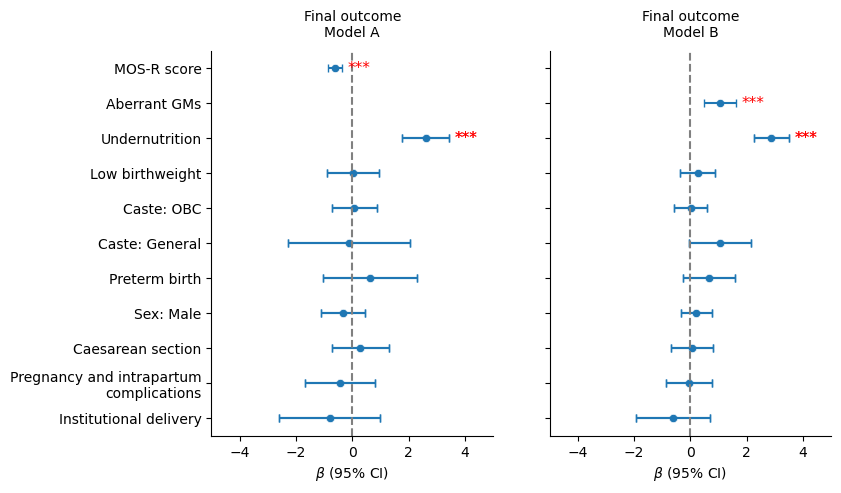

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (8,5), sharey = True)

scrs = pd.Series(['Final outcome A', 'Final outcome B'])
titles = ['Final outcome\nModel A', 'Final outcome\nModel B']

for i, scr in enumerate(scrs):
    data = DD_coefs[DD_coefs['Screening tool: outcome variable']==scr]
    data = data.merge(DD_coefs[['index', 'index_label']], how = 'right', on = ['index', 'index_label'])
    sns.scatterplot(
        data=data,
        y='index_label',
        x='coef',
        ax = ax[i])

    for _, row in data.iterrows():
        ax[i].errorbar(
            x=row['coef'],
            y=row['index_label'],
            xerr=[[row['coef'] - row['[0.025']],
                [row['0.975]'] - row['coef']]],
            fmt='none',
            capsize=3)

    for _, row in data.iterrows():
        if row['stars'] != '':
            ax[i].text(
                row['0.975]'] + 0.2,   # small horizontal shift
                row['index_label'],
                row['stars'],
                va='center',
                ha='left',
                fontsize=11,
                color = 'r')
    
    ax[i].axvline(0, linestyle='--', color='grey')
    
    xlab = 'log(Odds Ratio)' if scr!='GMA: MOS-R' else 'Estimate'
    ax[i].set_xlabel(r'$\beta\ (95\%\ \text{CI})$')
    model = data['Model'].unique()[0]

    ax[i].set_title(titles[i], fontsize = 10, pad = 10)
    ax[i].set_xlim(-5, 5)
    ax[i].set_xticks(np.arange(-4,5, 2))

sns.despine()
ax[0].set_ylabel('')
fig.savefig(
    "Model_estimates_DD.png",
    format="png",
    dpi=600,
    bbox_inches="tight")

plt.show()